In [ ]:
# download the dataset into dir
import subprocess, json, os, shutil

# TODO: Put your API Key
api_key = "API KEY"

# TODO: Replace GTID w/ your username
save_path = "/home/hice1/GTID/common_voice_25.tar.gz"

# Step 1: Get presigned download URL
response = subprocess.run([
    "curl", "-s", "-X", "POST",
    "https://datacollective.mozillafoundation.org/api/datasets/cmndapwry0
    "-H", f"Authorization: Bearer {api_key}"
    ,
    "-H", "Content-Type: application/json"
], capture_output=True, text=True)

data = json.loads(response.stdout)
download_url = data['downloadUrl']

print("Got download URL, starting download...")

# Step 2: Download to home directory
subprocess.run([
    "curl", "-o", save_path, download_url
])
print("Download complete!")
print(f"File size: {os.path.getsize(save_path) / (1024**3):.2f} GB")

Got download URL, starting download...


In [ ]:
# extract tar file
import tarfile
import os
# TODO Replace GTID with your username
save_path = "/home/hice1/GTID/common_voice_25.tar.gz"
extract_path = "/home/hice1/GTID/scratch"
try:
    with tarfile.open(save_path, 'r:gz') as tar:
        tar.extractall(extract_path)
except Exception as e:
print(f"Stopped at: {e}")
print("Extracted whatever was complete")
# See what we got
for f in os.listdir(extract_path): 
    print(f)

In [1]:
import os
# TODO: Replace GTID
base = "/home/hice1/mhasman3/scratch/cv-corpus-25.0-2026-03-09"
for f in os.listdir(base):
    print(f)

en


In [ ]:
# Print results to ensure dataset properly loaded 
en_path = os.path.join(base, "en")
print(os.listdir(en_path))

['reported.tsv', 'invalidated.tsv', 'dev.tsv', 'test.tsv', 'unvalidated_sentences.tsv', 'clips', 'other.tsv', 'train.tsv', 'validated_sentences.tsv', 'clip_durations.tsv', 'README.md', 'validated.tsv']


In [ ]:
# Print data entry
import pandas as pd
tsv_path = os.path.join(en_path, "validated.tsv")
df = pd.read_csv(tsv_path, sep="\t")
print(df.shape)
print(df.columns.tolist())
df.head()

/tmp/ipykernel_4156329/2741631514.py:3: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(tsv_path, sep="\t")


(1880682, 13)
['client_id', 'path', 'sentence_id', 'sentence', 'sentence_domain', 'up_votes', 'down_votes', 'age', 'gender', 'accents', 'variant', 'locale', 'segment']


,client_id,path,sentence_id,sentence,sentence_domain,up_votes,down_votes,age,gender,accents,variant,locale,segment
0,00095e762ba9e83fbffc38d3617aaeaa9bfd94d9f586c5...,common_voice_en_18127094.mp3,3343e59984bbb29777f68734d81dc9a9855b8c40d8b4ac...,"Yes, this is the right place.",NaN,2,0,NaN,NaN,NaN,NaN,en,NaN
1,000abb3006b78ea4c1144e55d9d158f05a9db011016051...,common_voice_en_27710027.mp3,b2cf0b3308b6e00b46f3e48fe59682452ae737a596aa29...,"Joe Keaton disapproved of films, and Buster al...",NaN,3,1,NaN,NaN,NaN,NaN,en,NaN
2,0013037a1d45cc33460806cc3f8ecee9d536c45639ba4c...,common_voice_en_699711.mp3,de9d68400821d73ee6868687d0562c60282ee9446d1191...,She'll be all right.,NaN,2,1,NaN,NaN,NaN,NaN,en,NaN
3,0014c5a3e5715a54855257779b89c2bb498d470b225866...,common_voice_en_21953345.mp3,14c0567a0a6c4ea49f2a1b2ac73de940b8c07779c70bf0...,six,NaN,3,2,NaN,NaN,NaN,NaN,en,Benchmark
4,001519f234e04528a2b36158c205dbe61c8da45ab0242f...,common_voice_en_27340672.mp3,a975540ad0c7ceaaec94cd17ae3b55e1eaf89a61d4a579...,It is a busy market town that serves a large s...,NaN,2,0,NaN,NaN,NaN,NaN,en,NaN


In [ ]:
# distribution of accent, age gender
for col in ["accents", "age", "gender"]:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).head(10))


--- accents ---
NaN                                                   843199
United States English                                 447120
England English                                       157679
India and South Asia (India, Pakistan, Sri Lanka)     110842
Canadian English                                       76997
Australian English                                     55498
Non native speaker|German English                      53295
Southern African (South Africa, Zimbabwe, Namibia)     26853
Scottish English                                       19390
New Zealand English                                    15198
Name: accents, dtype: int64

--- age ---
NaN          653901
twenties     457836
thirties     274950
fourties     174586
teens        111598
fifties      107192
sixties       83982
seventies     14535
eighties       1889
nineties        213
Name: age, dtype: int64

--- gender ---
male_masculine        879093
NaN                   691038
female_feminine       310341
do_no

Transcript: Yes, this is the right place.
Accent: nan
Age: nan
Gender: nan
Audio file: /home/hice1/mhasman3/scratch/cv-corpus-25.0-2026-03-09/en/clips/common_voice_en_18127094.mp3
Exists: True
Sample rate: 48000 Hz, Duration: 3.82s


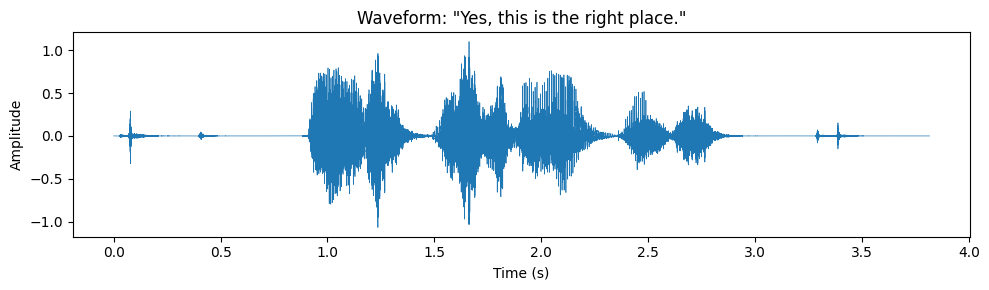

In [ ]:
# output one sample voice clip
import soundfile as sf
import IPython.display as ipd
import matplotlib.pyplot as plt
import numpy as np

clips_dir = os.path.join(en_path, "clips")
row = df.iloc[0]

print("Transcript:", row["sentence"])
print("Accent:", row["accents"])
print("Age:", row["age"])
print("Gender:", row["gender"])
audio_path = os.path.join(clips_dir, row["path"])
print("Audio file:", audio_path)
print("Exists:", os.path.exists(audio_path))

# Load audio
y, sr = sf.read(audio_path)
print(f"Sample rate: {sr} Hz, Duration: {len(y)/sr:.2f}s")

# Play inline
ipd.display(ipd.Audio(y, rate=sr))

# Waveform plot
plt.figure(figsize=(10, 3))
plt.plot(np.linspace(0, len(y)/sr, len(y)), y, linewidth=0.5)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title(f"Waveform: \"{row['sentence'][:60]}\"")
plt.tight_layout()
plt.show()